In [41]:

import pandas as pd

hisse_df = pd.read_csv("thyao_veri.csv", index_col=0, parse_dates=True)
print(hisse_df.tail())

                  Open        High         Low       Close    Volume
2024-12-25  282.319516  283.052179  281.098411  281.586853  12283659
2024-12-26  282.807975  286.471291  281.342649  283.296417  27141490
2024-12-27  283.540641  286.471294  283.052199  284.029083  23638402
2024-12-30  284.517544  284.761765  275.725586  275.725586  20734285
2024-12-31  275.969782  279.144655  272.306466  274.504456  26585935


In [42]:

# ── GENEL BİLGİ & İSTATİSTİKLER ────────────────────────────────────────────
print(f"Boyut        : {hisse_df.shape[0]:,} gün  x  {hisse_df.shape[1]} sütun")
print(f"Tarih aralığı: {hisse_df.index[0]}  →  {hisse_df.index[-1]}")
print(f"Eksik değer  : {hisse_df.isnull().sum().sum()}\n")
print("─" * 45)
print(hisse_df.info())


Boyut        : 3,858 gün  x  5 sütun
Tarih aralığı: 2010-01-01 00:00:00  →  2024-12-31 00:00:00
Eksik değer  : 0

─────────────────────────────────────────────
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3858 entries, 2010-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    3858 non-null   float64
 1   High    3858 non-null   float64
 2   Low     3858 non-null   float64
 3   Close   3858 non-null   float64
 4   Volume  3858 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 180.8 KB
None


## Görev 1 — Türetilmiş Özellik Mühendisliği (MA5, RSI, Günlük Getiri)

In [43]:
# hisse_df'yi bozmadan kopyasını alıyoruz
model_df = hisse_df.copy()

# ── 1) MA5: Son 5 günün kapanış ortalaması (kısa vadeli trend) ──────────────
model_df['MA5'] = model_df['Close'].rolling(window=5).mean()

# ── 2) RSI (14 günlük) ──────────────────────────────────────────────────────
delta = model_df['Close'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
model_df['RSI'] = 100 - (100 / (1 + gain / loss))

# ── 3) Günlük Getiri (%) ────────────────────────────────────────────────────
model_df['Daily_Return'] = model_df['Close'].pct_change() * 100

print(f"Orijinal sütunlar : {list(hisse_df.columns)}")
print(f"Yeni sütunlar     : {list(model_df.columns)}")
print(f"Toplam feature    : {model_df.shape[1]}")
model_df.head(20)


Orijinal sütunlar : ['Open', 'High', 'Low', 'Close', 'Volume']
Yeni sütunlar     : ['Open', 'High', 'Low', 'Close', 'Volume', 'MA5', 'RSI', 'Daily_Return']
Toplam feature    : 8


,Open,High,Low,Close,Volume,MA5,RSI,Daily_Return
2010-01-01,3.442062,3.442062,3.442062,3.442062,0,NaN,NaN,NaN
2010-01-04,3.472522,3.533444,3.350680,3.502983,11846086,NaN,NaN,1.769904
2010-01-05,3.502983,3.533444,3.472522,3.502983,7929532,NaN,NaN,0.000000
2010-01-06,3.502983,3.533444,3.411601,3.472522,9721300,NaN,NaN,-0.869575
2010-01-07,3.411601,3.442062,3.381140,3.411601,7407485,3.466430,NaN,-1.754379
2010-01-08,3.411601,3.442062,3.350680,3.350680,8583119,3.448154,NaN,-1.785693
2010-01-11,3.381140,3.411601,3.259297,3.350680,10830225,3.417693,NaN,0.000000
2010-01-12,3.320219,3.350680,3.228837,3.289758,10073647,3.375048,NaN,-1.818209
2010-01-13,3.289758,3.411601,3.259297,3.411601,13076455,3.362864,NaN,3.703710
2010-01-14,3.472522,3.533444,3.411601,3.472522,20038297,3.375048,NaN,1.785707


In [24]:
#Check if there is any null value in the dataset
model_df.isnull().sum()

Open             0
High             0
Low              0
Close            0
Volume           0
MA5              4
RSI             14
Daily_Return     1
dtype: int64

## Görev 2 — Hedef (Target) Değişkeni Oluşturma

**Hedef:** Yarınki kapanış bugünkünden yüksek mi?
- `1` → Yükseliş (Yukarı)
- `0` → Düşüş / Yatay (Aşağı)

Hedef Değişken Dağılımı:
  Düşüş    (0): 2,000 gün  (51.9%)
  Yükseliş (1): 1,857 gün  (48.1%)


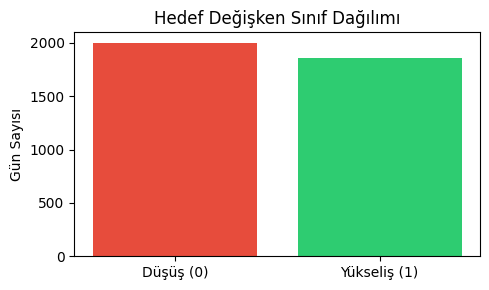

In [44]:
# shift(-1): yarınki kapanışı bugünün satırına getirir
# Eğer yarınki kapanış > bugünkü kapanış → 1, değilse → 0
import matplotlib.pyplot as plt

model_df['Target'] = (model_df['Close'].shift(-1) > model_df['Close']).astype(int)

# Son satırda yarınki veri yok → çıkar
model_df = model_df.iloc[:-1]

counts = model_df['Target'].value_counts()
print("Hedef Değişken Dağılımı:")
print(f"  Düşüş    (0): {counts[0]:,} gün  ({counts[0]/len(model_df)*100:.1f}%)")
print(f"  Yükseliş (1): {counts[1]:,} gün  ({counts[1]/len(model_df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Düşüş (0)', 'Yükseliş (1)'], [counts[0], counts[1]],
       color=['#e74c3c', '#2ecc71'])
ax.set_title('Hedef Değişken Sınıf Dağılımı')
ax.set_ylabel('Gün Sayısı')
plt.tight_layout()
plt.show()

In [26]:
model_df['Target'].isnull().sum()  

model_df.tail()

,Open,High,Low,Close,Volume,MA5,RSI,Daily_Return,Target
2024-12-24,279.388863,280.609968,276.702432,278.900421,15485512,281.586865,45.270223,-0.174822,1
2024-12-25,282.319516,283.052179,281.098411,281.586853,12283659,281.147260,42.553165,0.963223,1
2024-12-26,282.807975,286.471291,281.342649,283.296417,27141490,281.244946,32.499997,0.607118,1
2024-12-27,283.540641,286.471294,283.052199,284.029083,23638402,281.440326,34.146344,0.258622,0
2024-12-30,284.517544,284.761765,275.725586,275.725586,20734285,280.707672,27.631618,-2.923467,0


## Görev 3 — Veri Kalitesi Kontrolleri

### 3a. Eksik Değer Analizi

In [45]:
# ── EKSİK DEĞER ANALİZİ ─────────────────────────────────────────────────────
missing_info = model_df.isnull().sum()
missing_pct  = (missing_info / len(model_df) * 100).round(2)
missing_report = pd.DataFrame({'Eksik Sayı': missing_info, 'Eksik %': missing_pct})
missing_report = missing_report[missing_report['Eksik Sayı'] > 0]

print("Eksik değer içeren sütunlar (temizleme öncesi):")
if missing_report.empty:
    print("  → Hiç eksik değer yok.")
else:
    print(missing_report)

print(f"\nTemizleme öncesi satır sayısı: {len(model_df):,}")

# MA5 → ilk 4 satır, RSI → ilk ~14 satır, Daily_Return → ilk 1 satır NaN üretir.
# Bu NaN'lar gösterge pencerelerinin henüz dolmadığı başlangıç günlerinden gelir.
# Doldurmak anlamsız → siliyoruz.
model_df.dropna(inplace=True)

print(f"Temizleme sonrası satır sayısı: {len(model_df):,}")
print(f"Kalan eksik değer: {model_df.isnull().sum().sum()}")

Eksik değer içeren sütunlar (temizleme öncesi):
              Eksik Sayı  Eksik %
MA5                    4     0.10
RSI                   14     0.36
Daily_Return           1     0.03

Temizleme öncesi satır sayısı: 3,857
Temizleme sonrası satır sayısı: 3,843
Kalan eksik değer: 0


### 3b. Borsa Tatil Günü Kontrolü

In [28]:
# ── BORSA TATİL GÜNÜ KONTROLÜ ────────────────────────────────────────────────
# yfinance zaten sadece borsa açık günleri döndürür, ama doğrulayalım.

weekends = model_df[model_df.index.dayofweek >= 5]
print(f"Hafta sonu kayıt sayısı: {len(weekends)}  (0 = tatil günleri doğru şekilde hariç)")

# Ardışık işlem günleri arasındaki boşlukları kontrol et
gaps = model_df.index.to_series().diff().dt.days
large_gaps = gaps[gaps > 4]
print(f"Büyük boşluk (>4 gün) sayısı: {len(large_gaps)} — resmi tatil / bayram dönemleri")

if len(large_gaps) > 0:
    print("\nEn büyük 10 boşluk:")
    print(large_gaps.nlargest(10))

Hafta sonu kayıt sayısı: 0  (0 = tatil günleri doğru şekilde hariç)
Büyük boşluk (>4 gün) sayısı: 10 — resmi tatil / bayram dönemleri

En büyük 10 boşluk:
2023-02-15    7.0
2021-07-26    7.0
2024-04-15    7.0
2024-06-20    6.0
2023-07-03    6.0
2022-05-05    6.0
2020-08-04    5.0
2020-05-27    5.0
2022-07-13    5.0
2021-05-17    5.0
dtype: float64


### 3c. Feature–Target Korelasyon Analizi

Hangi feature'lar hedef değişken (Target) ile en güçlü ilişkiye sahip? Korelasyon haritası ile inceliyoruz.

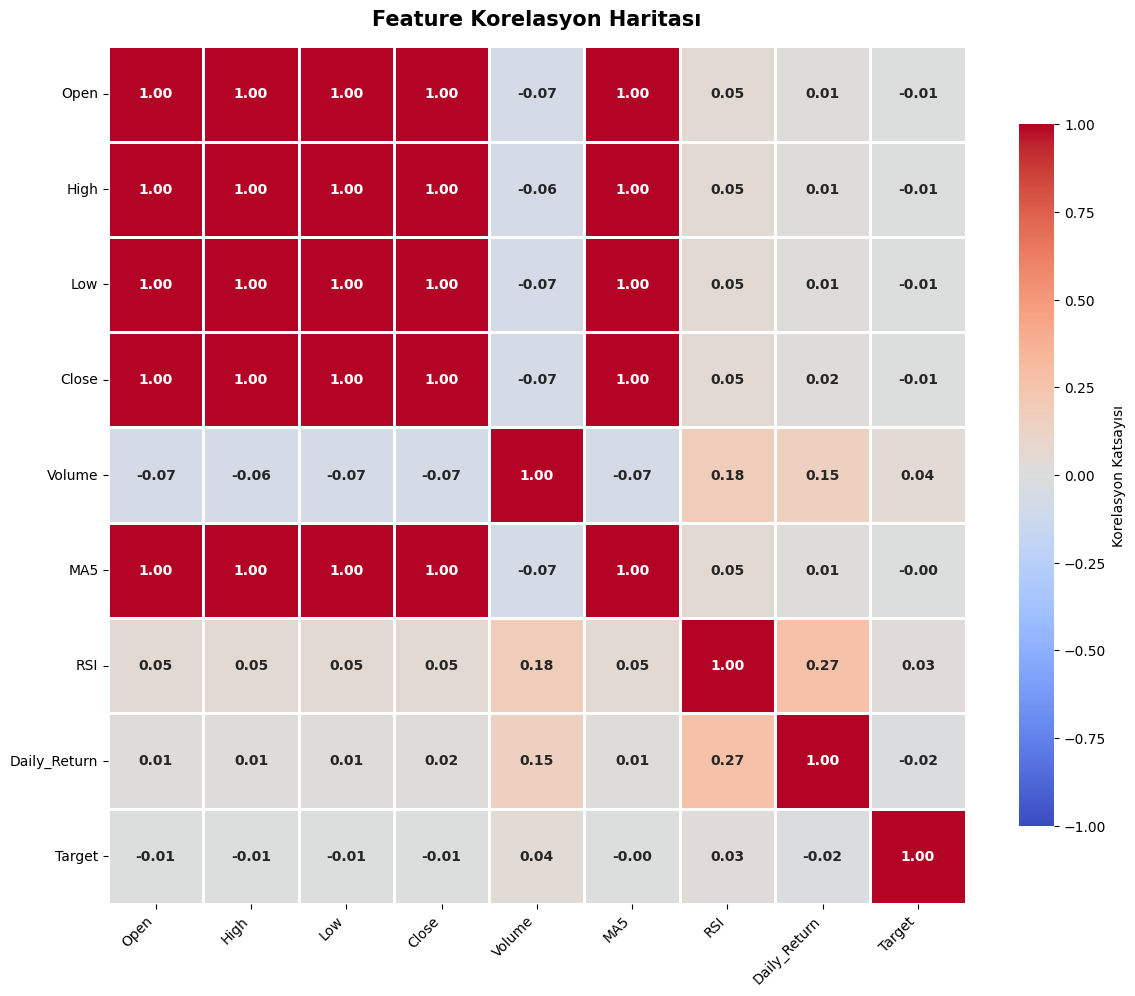

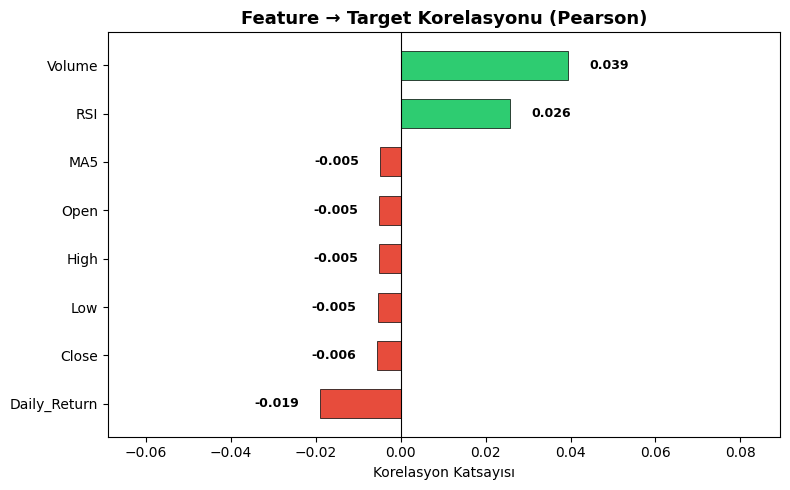

📊 Target ile en yüksek korelasyonlar:
  🟢 Volume          → +0.0394
  🟢 RSI             → +0.0258
  🔴 Daily_Return    → -0.0190
  🔴 Close           → -0.0056
  🔴 Low             → -0.0054
  🔴 High            → -0.0051
  🔴 Open            → -0.0051
  🔴 MA5             → -0.0049


In [46]:
import seaborn as sns
import numpy as np

# ── 1) TÜM FEATURE'LAR ARASI KORELASYON HARİTASI ────────────────────────────
corr_matrix = model_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white',
            annot_kws={'size': 10, 'fontweight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Korelasyon Katsayısı'},
            ax=ax)
ax.set_title('Feature Korelasyon Haritası', fontsize=15, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# ── 2) TARGET İLE KORELASYON (sıralı bar chart) ─────────────────────────────
target_corr = corr_matrix['Target'].drop('Target').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in target_corr.values]
bars = ax.barh(target_corr.index, target_corr.values, color=colors,
               edgecolor='black', linewidth=0.5, height=0.6)
ax.set_title('Feature → Target Korelasyonu (Pearson)', fontsize=13, fontweight='bold')
ax.set_xlabel('Korelasyon Katsayısı')
ax.axvline(0, color='black', lw=0.8)

for i, val in enumerate(target_corr.values):
    offset = 0.005 if val >= 0 else -0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, i, f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

ax.set_xlim(min(target_corr.values) - 0.05, max(target_corr.values) + 0.05)
plt.tight_layout()
plt.show()

print("📊 Target ile en yüksek korelasyonlar:")
for name, val in target_corr.abs().sort_values(ascending=False).items():
    arrow = "🟢" if corr_matrix.loc[name, 'Target'] > 0 else "🔴"
    print(f"  {arrow} {name:15s} → {corr_matrix.loc[name, 'Target']:+.4f}")

## Görev 4 — Model Eğitimi & Değerlendirme

### 4a. Walk-Forward Bölme & Normalizasyon

- **Başlangıç eğitim penceresi:** İlk %80 veri başlangıç eğitimi için ayrılır.
- **Walk-forward backtest:** Kalan %20 dönem zaman sırasını bozmadan ardışık fold'lara bölünür.
- **Her fold'da yeniden ölçekleme:** `MinMaxScaler` sadece o ana kadarki eğitim verisine `fit` edilir; sonraki fold yalnızca `transform` edilir.
- **Expanding window:** Her yeni fold geldiğinde eğitim kümesi zaman içinde genişler; gelecek verisi geçmişe sızmaz.

**Neden bu yaklaşım?** Zaman serilerinde tek bir sabit split, modelin farklı piyasa rejimlerinde nasıl davrandığını zayıf ölçer. Walk-forward yaklaşımı, her fold'da sadece geçmiş bilgiyi kullanarak daha gerçekçi bir backtest sağlar.

In [47]:
from sklearn.preprocessing import MinMaxScaler

# ── FEATURE / TARGET AYIRMA ─────────────────────────────────────────────────
DROPPED_FEATURES = ['Open', 'High', 'Low', 'MA5']
FEATURE_COLS = [
    col for col in model_df.columns
    if col not in DROPPED_FEATURES + ['Target']
 ]
X = model_df[FEATURE_COLS].values
y = model_df['Target'].values

# ── WALK-FORWARD İÇİN BAŞLANGIÇ EĞİTİM PENCERESİ ────────────────────────────
INITIAL_TRAIN_RATIO = 0.80
WF_N_SPLITS = 5
split_idx = int(len(X) * INITIAL_TRAIN_RATIO)

wf_test_indices = np.array_split(np.arange(split_idx, len(X)), WF_N_SPLITS)
wf_test_indices = [fold for fold in wf_test_indices if len(fold) > 0]
WF_N_SPLITS = len(wf_test_indices)

X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train,     y_test     = y[:split_idx], y[split_idx:]

print(f"Kaldırılan feature'lar: {DROPPED_FEATURES}")
print(f"Kullanılan feature'lar: {FEATURE_COLS}")
print(f"İlk eğitim penceresi : {len(X_train_raw):,} gün  ({model_df.index[0].date()} → {model_df.index[split_idx-1].date()})")
print(f"Walk-forward ufku    : {len(X_test_raw):,} gün  ({model_df.index[split_idx].date()} → {model_df.index[-1].date()})")
print(f"Fold sayısı          : {WF_N_SPLITS}")

# İlk eğitim penceresini görselleştirmek için ölçeklenmiş kopya tutuyoruz.
initial_scaler = MinMaxScaler()
X_train = initial_scaler.fit_transform(X_train_raw)
X_test  = initial_scaler.transform(X_test_raw)
scaler = initial_scaler

print(f"\nİlk eğitim tensörü: {X_train.shape}  |  İlk test tensörü: {X_test.shape}")
print(f"Feature'lar: {FEATURE_COLS}")

Kaldırılan feature'lar: ['Open', 'High', 'Low', 'MA5']
Kullanılan feature'lar: ['Close', 'Volume', 'RSI', 'Daily_Return']
İlk eğitim penceresi : 3,074 gün  (2010-01-21 → 2021-12-03)
Walk-forward ufku    : 769 gün  (2021-12-06 → 2024-12-30)
Fold sayısı          : 5

İlk eğitim tensörü: (3074, 4)  |  İlk test tensörü: (769, 4)
Feature'lar: ['Close', 'Volume', 'RSI', 'Daily_Return']


### 4a-1. Eğitim Seti Feature Dağılımları 


Her feature'ın dağılımını histogram + KDE ile inceliyoruz. Çarpık (skewed) veya çok uç değerli dağılımlar modeli olumsuz etkileyebilir.

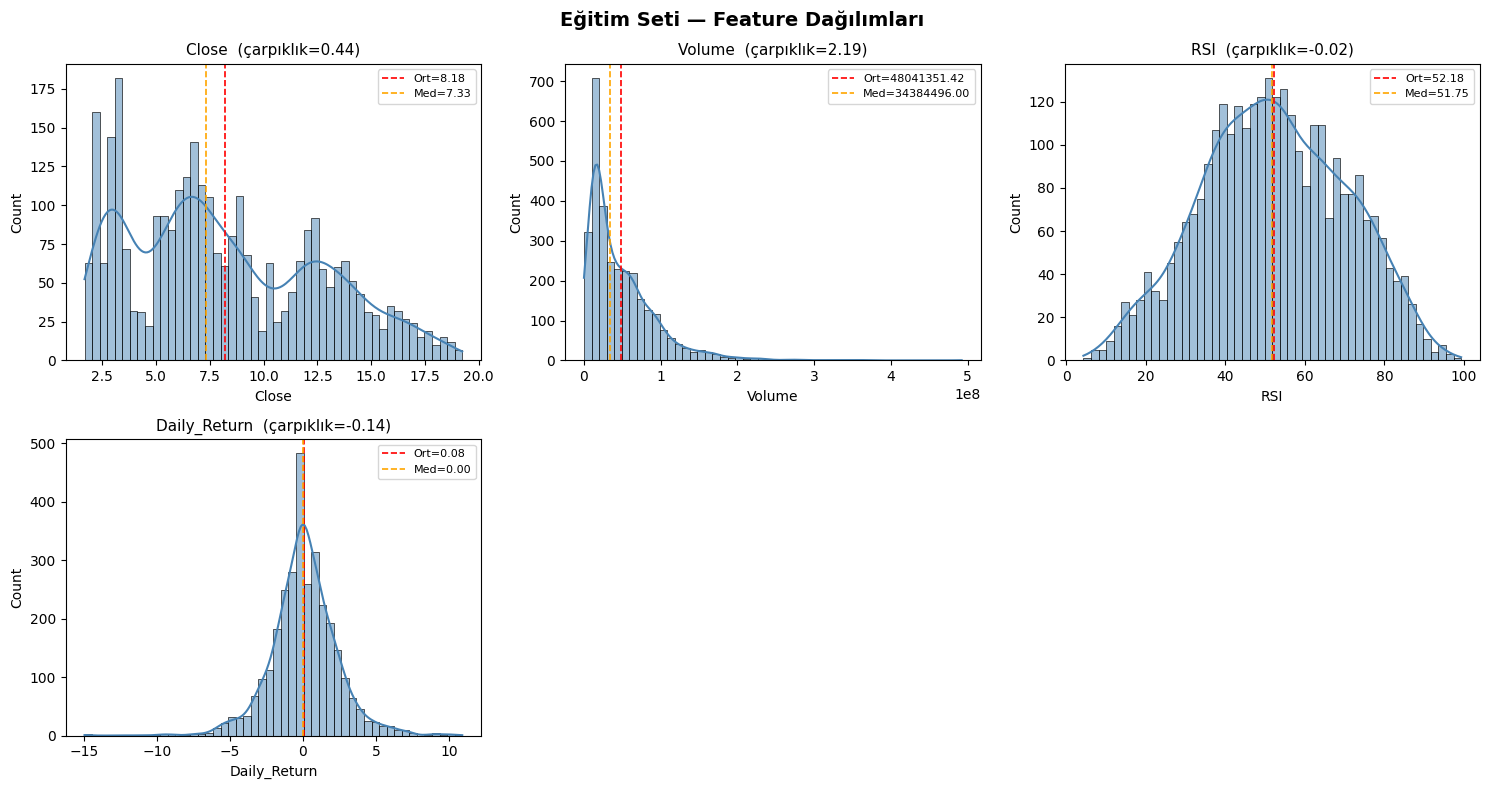


📊 Eğitim Seti İstatistik Özeti:


,mean,50%,std,min,max,skew,kurtosis
Close,8.181100e+00,7.331500e+00,4.380900e+00,1.6711,1.923490e+01,0.4402,-0.7878
Volume,4.804135e+07,3.438450e+07,4.491994e+07,0.0000,4.921997e+08,2.1856,8.6511
RSI,5.217590e+01,5.175060e+01,1.798420e+01,4.2618,9.931660e+01,-0.0224,-0.5672
Daily_Return,8.080000e-02,0.000000e+00,2.299900e+00,-14.9448,1.089740e+01,-0.1407,3.1780


In [31]:
import seaborn as sns

train_df = pd.DataFrame(X_train_raw, columns=FEATURE_COLS)

n_cols = 3
n_rows = (len(FEATURE_COLS) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    ax = axes[i]
    sns.histplot(train_df[col], kde=True, ax=ax, color='steelblue', bins=50)
    
    # İstatistikler
    mean = train_df[col].mean()
    med  = train_df[col].median()
    skew = train_df[col].skew()
    
    ax.axvline(mean, color='red', ls='--', lw=1.2, label=f'Ort={mean:.2f}')
    ax.axvline(med,  color='orange', ls='--', lw=1.2, label=f'Med={med:.2f}')
    ax.set_title(f'{col}  (çarpıklık={skew:.2f})', fontsize=11)
    ax.legend(fontsize=8)

# Boş grafikleri gizle
for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Eğitim Seti — Feature Dağılımları ', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# ── ÖZET TABLO ────────────────────────────────────────────────────────────────
desc = train_df.describe().T
desc['skew'] = train_df.skew()
desc['kurtosis'] = train_df.kurtosis()
print("\n📊 Eğitim Seti İstatistik Özeti:")
desc[['mean', '50%', 'std', 'min', 'max', 'skew', 'kurtosis']].round(4)

In [32]:
X_train

array([[0.09563019, 0.01936093, 0.40603284, 0.50920999],
       [0.09216156, 0.01378981, 0.30583979, 0.50795172],
       [0.09216156, 0.00959235, 0.30583979, 0.57830966],
       ...,
       [0.92880733, 0.3878125 , 0.53236883, 0.84572312],
       [0.91990826, 0.24664519, 0.51281151, 0.544679  ],
       [0.93548161, 0.37594468, 0.5482036 , 0.63767921]], shape=(3074, 4))

### 4b. LSTM — Kayan Pencere & Model

- **Kayan pencere = 20 gün:** Her örneklem `(20, n_features)` boyutunda tensör.
- **Dropout:** Aşırı öğrenmeyi önler.
- **EarlyStopping:** val_loss 10 epoch boyunca iyileşmezse durur, en iyi ağırlıkları geri yükler.

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import numpy as np

tf.random.set_seed(42)
np.random.seed(42)

# ── KAYAN PENCERE ────────────────────────────────────────────────────────────
WINDOW = 20

def create_sequences(X, y, window):
    """
    Eğitim sekanslarını üretir:
    X_seq[i] = X[i : i+window]
    y_seq[i] = y[i + window]
    """
    Xs, ys = [], []
    for i in range(len(X) - window):
        Xs.append(X[i : i + window])
        ys.append(y[i + window])
    return np.array(Xs), np.array(ys)

def create_eval_sequences(X_scaled, y, start_idx, end_idx, window):
    """
    Test sekanslarını üretirken geçmiş `window` günü de kullanır.
    Böylece her tahmin yalnızca kendisinden önceki günleri görür.
    """
    Xs, ys, target_indices = [], [], []
    for target_idx in range(start_idx, end_idx):
        if target_idx < window:
            continue
        Xs.append(X_scaled[target_idx - window : target_idx])
        ys.append(y[target_idx])
        target_indices.append(target_idx)
    return np.array(Xs), np.array(ys), np.array(target_indices)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, WINDOW)

print(f"İlk eğitim tensörü : {X_train_seq.shape}  (örneklem, pencere, feature)")
print(f"Walk-forward fold sayısı: {WF_N_SPLITS}")

İlk eğitim tensörü : (3054, 20, 4)  (örneklem, pencere, feature)
Walk-forward fold sayısı: 5


In [49]:
# Hyperparameters of Model

hyperparams = {
    "window": WINDOW,
    "epochs": 100,
    "batch_size": 32,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss_function": "binary_crossentropy",
    "early_stopping_patience": 4,
    "reduce_lr_patience": 2,
    "reduce_lr_factor": 0.5,
    "dropout_rates": 0.2,
    "lstm_units": 64,
    "dense_units": 16,
    "walk_forward_splits": WF_N_SPLITS,
    "initial_train_ratio": INITIAL_TRAIN_RATIO,
    "validation_split": 0.15,
    "shuffle": False,
    "train_samples": len(X_train_seq),
    "backtest_samples": len(X) - split_idx,
}

In [50]:
# ── LSTM MODEL ŞABLONU ───────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

n_features = X_train_seq.shape[2]

def build_lstm_model(hyperparams, n_features):
    model = Sequential([
        Input(shape=(hyperparams["window"], n_features)),
        LSTM(hyperparams["lstm_units"], return_sequences=True),
        Dropout(hyperparams["dropout_rates"]),
        LSTM(hyperparams["lstm_units"], return_sequences=True),
        Dropout(hyperparams["dropout_rates"]),
        LSTM(hyperparams["lstm_units"], return_sequences=False),
        Dropout(hyperparams["dropout_rates"]),
        Dense(hyperparams["dense_units"], activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=Adam(learning_rate=hyperparams["learning_rate"]),
        loss=hyperparams["loss_function"],
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(hyperparams, n_features)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 20, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 20, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,769 (331.13 KB)

 Trainable params: 84,769 (331.13 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# ── WALK-FORWARD EĞİTİM ──────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def walk_forward_lstm(X_raw, y, dates, test_folds, window, hyperparams):
    fold_summaries = []
    prob_batches, pred_batches, actual_batches, index_batches = [], [], [], []
    last_history = None
    last_model = None

    for fold_no, fold_indices in enumerate(test_folds, start=1):
        test_start = int(fold_indices[0])
        test_end = int(fold_indices[-1]) + 1

        scaler = MinMaxScaler()
        X_train_scaled = scaler.fit_transform(X_raw[:test_start])
        X_seen_scaled = scaler.transform(X_raw[:test_end])

        X_train_seq, y_train_seq = create_sequences(X_train_scaled, y[:test_start], window)
        X_fold_test_seq, y_fold_test, fold_target_indices = create_eval_sequences(
            X_seen_scaled, y, start_idx=test_start, end_idx=test_end, window=window
        )

        if len(X_train_seq) == 0 or len(X_fold_test_seq) == 0:
            continue

        weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train_seq)
        class_weights = {0: weights[0], 1: weights[1]}

        fold_model = build_lstm_model(hyperparams, n_features)
        history = fold_model.fit(
            X_train_seq, y_train_seq,
            epochs=hyperparams["epochs"],
            batch_size=hyperparams["batch_size"],
            validation_split=hyperparams["validation_split"],
            class_weight=class_weights,
            callbacks=[
                EarlyStopping(
                    monitor='val_loss',
                    patience=hyperparams["early_stopping_patience"],
                    restore_best_weights=True
                ),
                ReduceLROnPlateau(
                    monitor='val_loss',
                    factor=hyperparams["reduce_lr_factor"],
                    patience=hyperparams["reduce_lr_patience"],
                    min_lr=1e-7
                )
            ],
            shuffle=hyperparams["shuffle"],
            verbose=0
        )

        y_fold_prob = fold_model.predict(X_fold_test_seq, verbose=0).flatten()
        y_fold_pred = (y_fold_prob >= 0.5).astype(int)

        fold_auc = (
            roc_auc_score(y_fold_test, y_fold_prob)
            if len(np.unique(y_fold_test)) > 1 else float('nan')
        )

        fold_summary = {
            "fold": fold_no,
            "train_end": str(dates[test_start - 1].date()),
            "test_start": str(dates[test_start].date()),
            "test_end": str(dates[test_end - 1].date()),
            "train_samples": int(len(X_train_seq)),
            "test_samples": int(len(y_fold_test)),
            "accuracy": float(accuracy_score(y_fold_test, y_fold_pred)),
            "f1_score": float(f1_score(y_fold_test, y_fold_pred, zero_division=0)),
            "roc_auc": float(fold_auc),
        }
        fold_summaries.append(fold_summary)

        print(
            f"Fold {fold_no}/{len(test_folds)} | "
            f"Train sonu: {fold_summary['train_end']} | "
            f"Test: {fold_summary['test_start']} → {fold_summary['test_end']} | "
            f"Acc={fold_summary['accuracy']:.4f} | "
            f"F1={fold_summary['f1_score']:.4f} | "
            f"AUC={fold_summary['roc_auc']:.4f}"
        )

        prob_batches.append(y_fold_prob)
        pred_batches.append(y_fold_pred)
        actual_batches.append(y_fold_test)
        index_batches.append(fold_target_indices)
        last_history = history
        last_model = fold_model

    if not prob_batches:
        raise ValueError("Walk-forward için yeterli sekans üretilemedi.")

    return {
        "fold_results": pd.DataFrame(fold_summaries),
        "y_prob": np.concatenate(prob_batches),
        "y_pred": np.concatenate(pred_batches),
        "y_true": np.concatenate(actual_batches),
        "pred_indices": np.concatenate(index_batches),
        "last_history": last_history,
        "last_model": last_model,
    }

walk_forward_results = walk_forward_lstm(
    X_raw=X,
    y=y,
    dates=model_df.index,
    test_folds=wf_test_indices,
    window=WINDOW,
    hyperparams=hyperparams
)

fold_results = walk_forward_results["fold_results"]
y_prob = walk_forward_results["y_prob"]
y_pred = walk_forward_results["y_pred"]
y_test_seq = walk_forward_results["y_true"]
pred_indices = walk_forward_results["pred_indices"]
pred_dates = model_df.index[pred_indices]
history = walk_forward_results["last_history"]
model = walk_forward_results["last_model"]

print(f"\n✅ Walk-forward LSTM backtest tamamlandı. Toplam tahmin: {len(y_test_seq):,}")

Fold 1/5 | Train sonu: 2021-12-03 | Test: 2021-12-06 → 2022-07-18 | Acc=0.4156 | F1=0.0000 | AUC=0.5358
Fold 2/5 | Train sonu: 2022-07-18 | Test: 2022-07-19 → 2023-02-24 | Acc=0.4351 | F1=0.0000 | AUC=0.5931
Fold 3/5 | Train sonu: 2023-02-24 | Test: 2023-02-27 → 2023-10-09 | Acc=0.4675 | F1=0.3881 | AUC=0.4727
Fold 4/5 | Train sonu: 2023-10-09 | Test: 2023-10-10 → 2024-05-21 | Acc=0.4935 | F1=0.0000 | AUC=0.4956
Fold 5/5 | Train sonu: 2024-05-21 | Test: 2024-05-22 → 2024-12-30 | Acc=0.4314 | F1=0.3556 | AUC=0.4329

✅ Walk-forward LSTM backtest tamamlandı. Toplam tahmin: 769


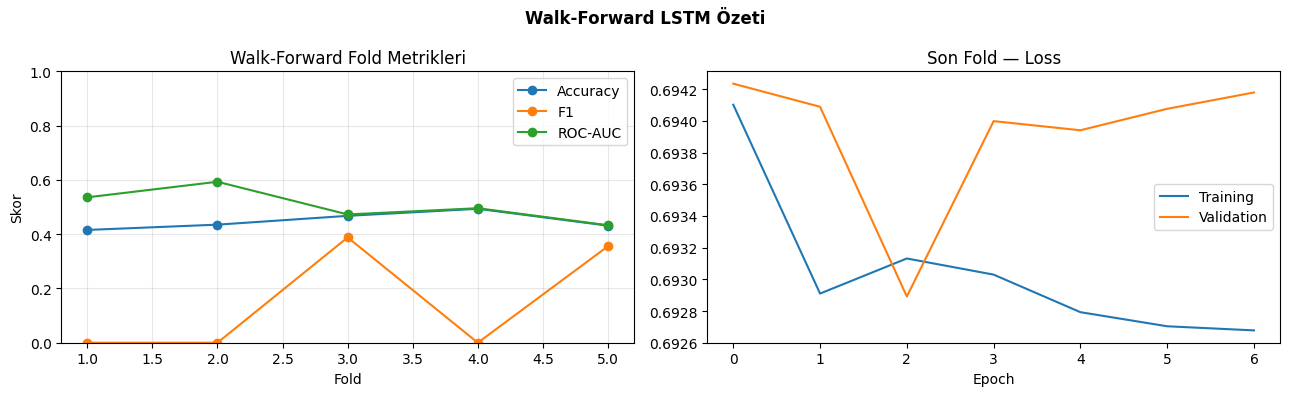

In [52]:
# ── WALK-FORWARD ÖZET GRAFİKLERİ ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(fold_results['fold'], fold_results['accuracy'], marker='o', label='Accuracy')
ax1.plot(fold_results['fold'], fold_results['f1_score'], marker='o', label='F1')
ax1.plot(fold_results['fold'], fold_results['roc_auc'], marker='o', label='ROC-AUC')
ax1.set_title('Walk-Forward Fold Metrikleri')
ax1.set_xlabel('Fold')
ax1.set_ylabel('Skor')
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(history.history['loss'], label='Training')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Son Fold — Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.suptitle('Walk-Forward LSTM Özeti', fontweight='bold')
plt.tight_layout()
plt.show()

### 4c. Walk-Forward Değerlendirme Metrikleri

| Metrik | Açıklama |
|---|---|
| **Accuracy** | Tüm fold'lardaki toplam doğru tahmin / toplam tahmin |
| **Precision** | Yükseliş tahminlerinin kaçı gerçekten yükseliş? |
| **Recall** | Gerçekte yükseliş olan günlerin kaçını yakaladı? |
| **F1 Score** | Precision & Recall harmonik ortalaması |
| **Confusion Matrix** | Tüm walk-forward tahminlerinin doğru/yanlış dağılımı |
| **ROC-AUC** | Toplu backtest ayırt etme gücü |

In [53]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ── TOPLU WALK-FORWARD METRİKLERİ ───────────────────────────────────────────
acc  = accuracy_score(y_test_seq, y_pred)
prec = precision_score(y_test_seq, y_pred, zero_division=0)
rec  = recall_score(y_test_seq, y_pred, zero_division=0)
f1   = f1_score(y_test_seq, y_pred, zero_division=0)
auc  = roc_auc_score(y_test_seq, y_prob) if len(np.unique(y_test_seq)) > 1 else float('nan')

print("=" * 50)
print("       WALK-FORWARD LSTM SONUÇLARI")
print("=" * 50)
print(f"  Fold Sayısı : {len(fold_results)}")
print(f"  Tahmin Günü : {len(y_test_seq):,}")
print(f"  Accuracy    : {acc:.4f}")
print(f"  Precision   : {prec:.4f}")
print(f"  Recall      : {rec:.4f}")
print(f"  F1 Score    : {f1:.4f}")
print(f"  ROC-AUC     : {auc:.4f}")
print("=" * 50)

fold_results.round(4)

       WALK-FORWARD LSTM SONUÇLARI
  Fold Sayısı : 5
  Tahmin Günü : 769
  Accuracy    : 0.4486
  Precision   : 0.3906
  Recall      : 0.1263
  F1 Score    : 0.1908
  ROC-AUC     : 0.4392


,fold,train_end,test_start,test_end,train_samples,test_samples,accuracy,f1_score,roc_auc
0,1,2021-12-03,2021-12-06,2022-07-18,3054,154,0.4156,0.0000,0.5358
1,2,2022-07-18,2022-07-19,2023-02-24,3208,154,0.4351,0.0000,0.5931
2,3,2023-02-24,2023-02-27,2023-10-09,3362,154,0.4675,0.3881,0.4727
3,4,2023-10-09,2023-10-10,2024-05-21,3516,154,0.4935,0.0000,0.4956
4,5,2024-05-21,2024-05-22,2024-12-30,3670,153,0.4314,0.3556,0.4329


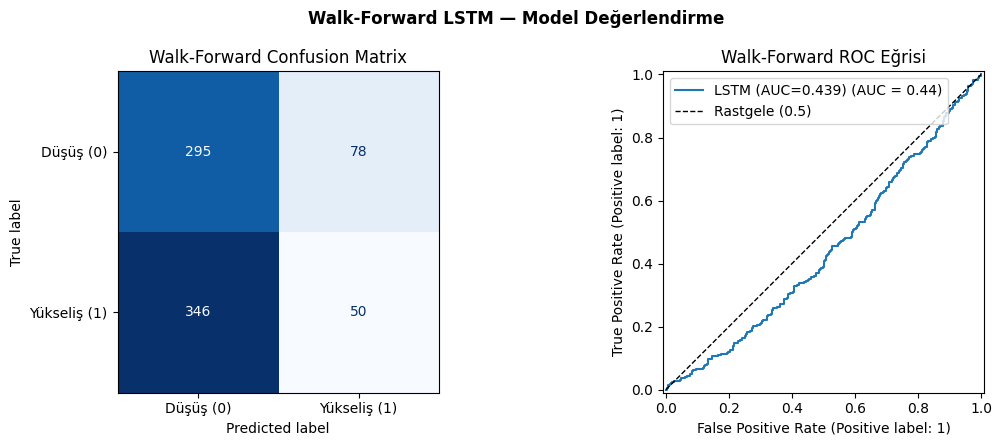

In [54]:
# ── CONFUSION MATRIX & ROC EĞRİSİ (WALK-FORWARD) ────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Confusion Matrix
cm = confusion_matrix(y_test_seq, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Düşüş (0)', 'Yükseliş (1)']).plot(
    ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Walk-Forward Confusion Matrix')

# ROC Eğrisi
RocCurveDisplay.from_predictions(
    y_test_seq, y_prob, ax=ax2,
    name=f'LSTM (AUC={auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1, label='Rastgele (0.5)')
ax2.set_title('Walk-Forward ROC Eğrisi')
ax2.legend()

plt.suptitle('Walk-Forward LSTM — Model Değerlendirme', fontweight='bold')
plt.tight_layout()
plt.show()

### 4d. Walk-Forward Log Kaydı

Her eğitim çalıştırıldığında aşağıdaki bilgiler `logs/` klasörüne otomatik kaydedilir:
- **Model mimarisi** (son fold modeli)
- **Hiperparametreler** (`WINDOW`, `epochs`, `batch_size`, `learning_rate`, fold sayısı vb.)
- **Toplu değerlendirme metrikleri** (Accuracy, Precision, Recall, F1, AUC)
- **Fold bazlı walk-forward sonuçları** (`JSON`)
- **Fold metrik özeti** (`PNG`)

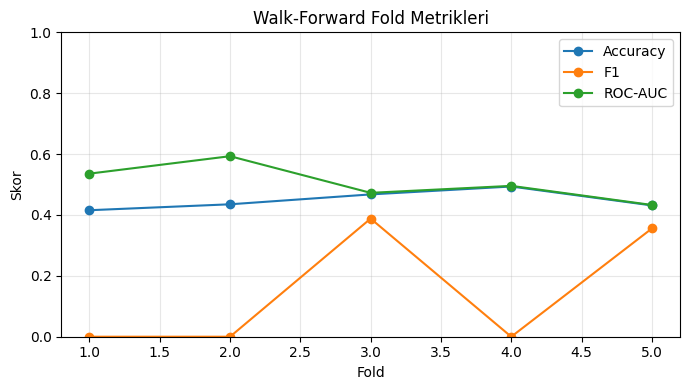

✅ Log kaydı tamamlandı → logs\20260422_173658/
   ├── model_summary.txt
   ├── hyperparameters.json
   ├── metrics.json
   ├── walk_forward_folds.json
   └── walk_forward_metrics.png

📊 Metrikler: Acc=0.4486 | F1=0.1908 | AUC=0.4392


In [55]:
import os, json
from datetime import datetime

# ── LOG KLASÖRÜ OLUŞTUR ──────────────────────────────────────────────────────
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_dir = os.path.join("logs", timestamp)
os.makedirs(log_dir, exist_ok=True)

# ── 1) MODEL MİMARİSİ ────────────────────────────────────────────────────────
summary_lines = []
model.summary(print_fn=lambda x: summary_lines.append(x))
model_summary = "\n".join(summary_lines)

with open(os.path.join(log_dir, "model_summary.txt"), "w", encoding="utf-8") as f:
    f.write(model_summary)

# ── 2) HİPERPARAMETRELER ────────────────────────────────────────────────────
with open(os.path.join(log_dir, "hyperparameters.json"), "w", encoding="utf-8") as f:
    json.dump(hyperparams, f, indent=2, ensure_ascii=False)

# ── 3) TOPLU METRİKLER ───────────────────────────────────────────────────────
metrics = {
    "evaluation_method": "walk_forward",
    "initial_train_ratio": round(INITIAL_TRAIN_RATIO, 2),
    "walk_forward_splits": int(WF_N_SPLITS),
    "evaluated_samples": int(len(y_test_seq)),
    "accuracy": round(acc, 4),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(auc, 4),
}

with open(os.path.join(log_dir, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

with open(os.path.join(log_dir, "walk_forward_folds.json"), "w", encoding="utf-8") as f:
    json.dump(fold_results.round(4).to_dict(orient="records"), f, indent=2, ensure_ascii=False)

# ── 4) FOLD METRİK GRAFİĞİ → PNG ─────────────────────────────────────────────
fig_curves, ax = plt.subplots(figsize=(7, 4))
ax.plot(fold_results['fold'], fold_results['accuracy'], marker='o', label='Accuracy')
ax.plot(fold_results['fold'], fold_results['f1_score'], marker='o', label='F1')
ax.plot(fold_results['fold'], fold_results['roc_auc'], marker='o', label='ROC-AUC')
ax.set_title('Walk-Forward Fold Metrikleri')
ax.set_xlabel('Fold')
ax.set_ylabel('Skor')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig_curves.savefig(os.path.join(log_dir, "walk_forward_metrics.png"), dpi=150, bbox_inches='tight')
plt.show()

# ── ÖZET ─────────────────────────────────────────────────────────────────────
print(f"✅ Log kaydı tamamlandı → {log_dir}/")
print(f"   ├── model_summary.txt")
print(f"   ├── hyperparameters.json")
print(f"   ├── metrics.json")
print(f"   ├── walk_forward_folds.json")
print(f"   └── walk_forward_metrics.png")
print(f"\n📊 Metrikler: Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f}")